# Local-stim response analysis (exp_426)

Loads the exported zarr + `exp_data.parquet` from a random-patch stim run and:

1. Pulls the mean intensity inside each cell's 14 px stim patch (both imaging channels), per timepoint, and merges back onto `df_exp`.
2. Provides cell-level QC filters (mean expression per channel, area).
3. Picks a deterministic random *control* patch from the same cell Ã¢â‚¬— same selection algorithm but excluding the stim patch Ã¢â‚¬— and measures intensity there too, so each cell carries its own unstimulated baseline.
4. Plots per-channel mean response over time for stim vs. control patches.
5. Extracts 128 px windows around each stim patch and computes texture / shape features so we can correlate local response with cell structure.

In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import sobel

# ---- Edit for the run ----
BASE_PATH       = r"Z:\lhinder\data\rtm_mm_data\exp_436"
EXPERIMENT_NAME = "random_stim"
PATCH_SIZE      = 14   # must match the stimulator (RandomStimPerCell14pxPatches.PATCH_SIZE)
DOT_DIAMETER    = 10   # ditto, for the actually-illuminated dot inside each patch
TEXTURE_PATCH   = 52  # square window around the stim patch for texture feats

# Imaging channel names *in the order they appear on the C axis of the raw zarr*.
# Order = imaging channels first (as passed to the experiment), then stim readouts.
IMAGING_CHANNELS = ["mScarlet3", "miRFP"]

path = Path(BASE_PATH) / EXPERIMENT_NAME
print("experiment dir:", path)
print("exists:", path.is_dir())

experiment dir: Z:\lhinder\data\rtm_mm_data\exp_436\random_stim
exists: False


# to analyze
- whole cell area, cells seem to contract under ERK activation
- local intensity of PIP at stim location
- formation of new ruffles? draw line from centroid to stim location, and look at intersection of cell outline, this is where ruffles seem to form/inversely check oppisite site for disappearence. also check closest location.
- how to segment the nuc channel to get ERK-KTR? train on ERK-KTR, stadist or cellpose to detect nuclei, get some kind of confidence, for low confidence interpolate? train on cell line with H2B so we don't have to annotate
- do next experiments with much less stimulation power, so nb cells that activate/dont activate ERK are around 50/50
- figure whats non-starving?

In [6]:
df_exp = pd.read_parquet(path / "exp_data.parquet")
print(df_exp.shape)
print(df_exp.columns.tolist())
df_exp.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Z:\\lhinder\\data\\rtm_mm_data\\exp_436\\random_stim\\exp_data.parquet'

In [3]:
# OmeZarrWriter direct-mode layout: <root>/0 has shape (T, P, C, Y, X).
# Labels live at <root>/labels/<name>/0 with shape (T, P, Y, X).
store = zarr.open(str(path / "acquisition.ome.zarr"), mode="r")
raw   = store["0"]
print("raw shape:", raw.shape, "dtype:", raw.dtype)

labels = None
for name in ("particles", "labels"):  # prefer tracked labels if present
    try:
        labels = store[f"labels/{name}/0"]
        print(f"labels: {name}/0 shape={labels.shape}")
        break
    except KeyError:
        continue
if labels is None:
    raise RuntimeError("No labels array found under labels/particles or labels/labels.")

T, P, C, H, W = raw.shape
ch_idx = {name: i for i, name in enumerate(IMAGING_CHANNELS)}
print("T, P, C, H, W =", T, P, C, H, W)
print("imaging channel index map:", ch_idx)

FileNotFoundError: Z:\lhinder\data\rtm_mm_data\exp_436\random_stim_per_cell_14px_patches\acquisition.ome.zarr does not exist

## 0. (Optional) Reconstruct missing `patch_*` columns

If the post-experiment `stimulator.to_dataframe()` merge wasn't run on the rig, `exp_data.parquet` is missing the per-cell patch coordinates. This cell rebuilds them from the saved per-frame labels using the stimulator's deterministic seed and writes the merged parquet back to disk. It's a no-op when patch columns are already populated, so it's safe to leave in the flow.

In [5]:
# Reconstruct patch_* columns from saved data if they're missing from
# exp_data.parquet (i.e. the post-experiment stimulator.to_dataframe() merge
# was forgotten). Mirrors RandomStimPerCell14pxPatches's RNG and selection.
#
# IMPORTANT BUG-FIX vs the original to_dataframe() merge:
# The stimulator caches its per-cell selection at the FIRST stim frame and
# re-emits records carrying the SAME first-frame seg label at every
# subsequent stim frame. Per-frame seg labels are NOT stable across frames
# (Cellpose renumbers each frame), so merging the records on
# (fov, fov_timestep, label) attaches the same patch coords to whichever
# row happens to share that seg label at the later frame -- i.e. a
# DIFFERENT cell. We instead resolve each first-frame seg label to its
# tracked particle id, then merge on (fov, fov_timestep, particle), which
# is stable across the whole timecourse.
#
# Writes the merged exp_data.parquet back to disk so subsequent runs
# can skip the rebuild.

# ---- Must match the values used on the rig ----
STIM_BASE_SEED   = 0   # RandomStimPerCell14pxPatches(seed=...) at run time
STIM_PATCH_SIZE  = 14  # PATCH_SIZE class attr
# (DOT_DIAMETER does not affect patch coords, only the stim mask itself.)

# Force a rebuild even if the columns are already populated -- needed once
# to overwrite a previously-broken label-based merge. Flip to False after
# the first successful particle-based run.
FORCE_RECONSTRUCT = True

PATCH_COLS = [
    "patch_i", "patch_j",
    "patch_y_min", "patch_x_min", "patch_y_max", "patch_x_max",
    "patch_dot_y", "patch_dot_x",
]

_have_cols   = all(c in df_exp.columns for c in PATCH_COLS)
_have_values = _have_cols and df_exp[PATCH_COLS].notna().any(axis=1).any()
needs_reconstruction = FORCE_RECONSTRUCT or not _have_values
print("patch_* columns present:", _have_cols, "  with values:", _have_values,
      "  -> rebuilding:", needs_reconstruction)

if needs_reconstruction:
    if "particle" not in df_exp.columns:
        raise RuntimeError(
            "df_exp has no 'particle' column -- the particle-based merge can't "
            "run. Re-track the experiment or fall back to a label-based merge."
        )

    # The live stimulator received per-frame segmentation labels, not tracked
    # particle ids. Reload labels/labels/0 explicitly -- the open-zarr cell
    # above preferred particles for downstream use.
    labels_perframe = zarr.open(str(path / "acquisition.ome.zarr"), mode="r")[
        "labels/labels/0"
    ]
    print("labels/labels/0 shape:", labels_perframe.shape)

    def _select_patch_per_cell(labels_frame: np.ndarray, rng, patch_size: int) -> dict:
        ps = patch_size
        h, w = labels_frame.shape
        n_h, n_w = h // ps, w // ps
        if n_h == 0 or n_w == 0:
            return {}
        cropped = labels_frame[: n_h * ps, : n_w * ps]
        blocks = cropped.reshape(n_h, ps, n_w, ps)
        block_min = blocks.min(axis=(1, 3))
        block_max = blocks.max(axis=(1, 3))
        uniform = (block_min == block_max) & (block_min != 0)
        if not uniform.any():
            return {}
        ii, jj = np.nonzero(uniform)
        cell_labels = block_min[ii, jj]
        out: dict[int, tuple[int, int]] = {}
        for label in np.unique(cell_labels):
            mask = cell_labels == label
            choices = np.flatnonzero(mask)
            chosen = int(rng.integers(choices.size))
            out[int(label)] = (
                int(ii[choices[chosen]]),
                int(jj[choices[chosen]]),
            )
        return out

    # stim_power is filled in only on stim frames by the rig event loop, so
    # it's the most reliable per-row stim flag. Fall back to the bool `stim`
    # column if power wasn't recorded.
    if "stim_power" in df_exp.columns and df_exp["stim_power"].notna().any():
        stim_flag = df_exp["stim_power"].notna()
    else:
        stim_flag = df_exp["stim"].astype(bool)
    stim_rows_raw = df_exp[stim_flag]
    first_stim_per_fov = (
        stim_rows_raw.groupby("fov")["fov_timestep"]
        .min()
        .astype(int)
        .to_dict()
    )
    print("first stim frame per FOV:", first_stim_per_fov)

    records: list[dict] = []
    n_unmapped = 0
    for fov, t_first in first_stim_per_fov.items():
        fov = int(fov)
        seed = (
            STIM_BASE_SEED * 2_654_435_761 + fov * 1_000_003
        ) & 0xFFFFFFFF
        rng = np.random.default_rng(seed)
        fov_labels = np.asarray(labels_perframe[t_first, fov])
        per_cell = _select_patch_per_cell(fov_labels, rng, STIM_PATCH_SIZE)
        if not per_cell:
            print(f"  fov={fov}: no eligible patches at t={t_first}")
            continue

        # Resolve first-frame seg label -> particle id by joining against
        # df_exp at the first stim frame. Without this, the merge below
        # would attach the same coords to whichever cell shares the label
        # at later frames.
        first_frame_rows = df_exp[
            (df_exp["fov"] == fov) & (df_exp["fov_timestep"] == t_first)
        ][["label", "particle"]].dropna(subset=["particle"])
        label_to_particle = dict(
            zip(
                first_frame_rows["label"].astype(int),
                first_frame_rows["particle"].astype(int),
            )
        )

        fov_stim_t = sorted(
            stim_rows_raw[stim_rows_raw["fov"] == fov]["fov_timestep"]
            .unique()
            .astype(int)
        )

        for cell_label, (i, j) in per_cell.items():
            particle = label_to_particle.get(int(cell_label))
            if particle is None:
                # Stimulator picked a cell that wasn't tracked at first
                # stim frame -- drop, we can't propagate it safely.
                n_unmapped += 1
                continue
            y0, x0 = i * STIM_PATCH_SIZE, j * STIM_PATCH_SIZE
            for t in fov_stim_t:
                records.append(
                    {
                        "fov": fov,
                        "fov_timestep": int(t),
                        "particle": int(particle),
                        "patch_i": i,
                        "patch_j": j,
                        "patch_y_min": y0,
                        "patch_x_min": x0,
                        "patch_y_max": y0 + STIM_PATCH_SIZE,
                        "patch_x_max": x0 + STIM_PATCH_SIZE,
                        "patch_dot_y": y0 + (STIM_PATCH_SIZE - 1) / 2,
                        "patch_dot_x": x0 + (STIM_PATCH_SIZE - 1) / 2,
                    }
                )
    if n_unmapped:
        print(f"dropped {n_unmapped} untracked-at-first-stim-frame cells")

    df_patches = pd.DataFrame(records).drop_duplicates(
        subset=["fov", "fov_timestep", "particle"]
    )
    print(f"reconstructed {len(df_patches)} patch records "
          f"({df_patches['fov'].nunique() if len(df_patches) else 0} FOVs, "
          f"{df_patches['particle'].nunique() if len(df_patches) else 0} particles)")

    df_exp = df_exp.drop(
        columns=[c for c in PATCH_COLS if c in df_exp.columns],
        errors="ignore",
    ).merge(df_patches, on=["fov", "fov_timestep", "particle"], how="left")

    n_with_patch = df_exp[PATCH_COLS[0]].notna().sum()
    print(f"df_exp rows with reconstructed patch coords: {n_with_patch}")

    exp_data_path = path / "exp_data.parquet"
    df_exp.to_parquet(exp_data_path)
    print("wrote:", exp_data_path)


patch_* columns present: True   with values: True   -> rebuilding: True
labels/labels/0 shape: (75, 34, 800, 1024)
first stim frame per FOV: {0: 15, 1: 15, 2: 15, 3: 15, 4: 15, 5: 15, 6: 15, 7: 15, 8: 15, 9: 15, 10: 15, 11: 15, 12: 15, 13: 15, 14: 15, 15: 15, 16: 15, 17: 15, 18: 15, 19: 15, 20: 15, 21: 15, 22: 15, 23: 15, 24: 15, 25: 15, 26: 15, 27: 15, 28: 15, 29: 15, 30: 15, 31: 15, 32: 15, 33: 15}
reconstructed 19560 patch records (34 FOVs, 43 particles)
df_exp rows with reconstructed patch coords: 19039
wrote: Z:\lhinder\data\rtm_mm_data\exp_434\random_stim_per_cell_14px_patches\exp_data.parquet


## 1. Load the analysis helper

Processing lives in `stim_analysis.py` next to this notebook. Re-execute this cell after editing the module to pick up changes without restarting the kernel.

In [6]:
import importlib
import stim_analysis as sa
importlib.reload(sa)
print([n for n in dir(sa) if not n.startswith("_")])

['DINOv3JafarPatch', 'DINOv3Patch', 'FeatureExtractor', 'GLCMTexture', 'Iterable', 'MeanIntensity', 'Protocol', 'annotations', 'baseline_normalize', 'build_patches_long', 'candidate_patches_for_cell', 'cluster_dino_features', 'dataclass', 'dino_feature_map', 'dino_features_pca_rgb', 'dino_features_pca_rgb_per_cell', 'extract_features', 'field', 'fit_response_classifier', 'fit_response_regressor', 'make_cell_mask_loader', 'make_dot_mask', 'np', 'pd', 'per_cell_dino_vector', 'per_cell_response_metric', 'pivot_roles', 'plot_patch_overlays', 'predict_response_map', 'runtime_checkable', 'select_control_patches', 'tqdm']


## 2. Build the patches table (stim + control)

One row per `(fov, particle, role)`. Control patches are picked on the *tracked-particle* label image at each cell's first stim frame, deterministically seeded from `(fov, particle)` so a re-run gives the same control.

Nothing has been read off the imaging zarr yet  -  this is cheap and re-runnable.

In [7]:
# stim_table = first stim row per (fov, particle). Carry the per-frame
# seg label too because control eligibility runs on labels/labels/0
# (where every cell has a unique non-zero id) - particles/0 collides
# real particle=0 with background.
stim_table = (
    df_exp.dropna(subset=["patch_i", "patch_j"])
    .sort_values("fov_timestep")
    .groupby(["fov", "particle"])
    .first()
    .reset_index()[["fov", "particle", "fov_timestep", "patch_i", "patch_j", "label"]]
)
print(f"{len(stim_table)} stim cells")

# Number of control patches per cell. K > 1 shrinks the per-cell control
# sampling variance by ~1/sqrt(K), so the stim-vs-ctrl baseline scatter
# tightens onto the diagonal. extract_features averages the K control
# patches per (cell, frame) automatically.
N_CONTROLS = 1

labels_seg = zarr.open(str(path / "acquisition.ome.zarr"), mode="r")["labels/labels/0"]
_label_cache: dict[tuple[int, int], np.ndarray] = {}
def _seg_labels_loader(t: int, fov: int) -> np.ndarray:
    key = (int(t), int(fov))
    if key not in _label_cache:
        _label_cache[key] = np.asarray(labels_seg[t, fov])
    return _label_cache[key]

ctrl_table = sa.select_control_patches(
    stim_table, _seg_labels_loader,
    cell_id_col="label",
    n_controls=N_CONTROLS,
    patch_size=PATCH_SIZE,
)
n_cells_with_ctrl = ctrl_table["particle"].nunique() if len(ctrl_table) else 0
print(f"{n_cells_with_ctrl} cells got control patches "
      f"(avg {len(ctrl_table)/max(1, n_cells_with_ctrl):.1f} per cell, K={N_CONTROLS} requested)")

patches_long = sa.build_patches_long(df_exp, ctrl_table)
print(f"patches_long: {len(patches_long)} rows {patches_long['role'].value_counts().to_dict()}")
patches_long.head()

652 stim cells
43 cells got control patches (avg 14.4 per cell, K=1 requested)
patches_long: 1272 rows {'stim': 652, 'control': 620}


,fov,particle,y_min,x_min,role
0,0,1,112,476,stim
1,0,2,154,630,stim
2,0,3,168,294,stim
3,0,4,238,994,stim
4,0,5,252,770,stim


### 2b. Diagnostic: are patches actually inside their cells?

Sanity-check the stim + control selection before we burn cycles on extraction.  Loads `labels/labels/0` (per-frame seg labels) and verifies each cell's stim and control patches are fully inside the tracked particle at the first stim frame. If `stim_in_particle` is mostly False the seg-label -> particle mapping in the reconstruction broke; if `ctrl_in_particle` is mostly False the control selection logic is wrong.  Also reports the unique seg-label IDs under each stim patch -- if anything other than the expected cell shows up, that's the bug.

In [8]:
labels_perframe_diag = zarr.open(str(path / "acquisition.ome.zarr"), mode="r")["labels/labels/0"]

diag_rows = []
for _, row in stim_table.head(60).iterrows():
    fov, particle, t = int(row["fov"]), int(row["particle"]), int(row["fov_timestep"])
    pi, pj = int(row["patch_i"]), int(row["patch_j"])
    sy0, sx0 = pi * PATCH_SIZE, pj * PATCH_SIZE

    p_lbl = np.asarray(labels[t, fov])
    s_lbl = np.asarray(labels_perframe_diag[t, fov])

    stim_block_part = p_lbl[sy0:sy0 + PATCH_SIZE, sx0:sx0 + PATCH_SIZE]
    stim_block_seg  = s_lbl[sy0:sy0 + PATCH_SIZE, sx0:sx0 + PATCH_SIZE]
    stim_in_part = bool((stim_block_part == particle).all())
    seg_uniq = tuple(int(v) for v in np.unique(stim_block_seg))

    ctrl_match = ctrl_table[(ctrl_table["fov"] == fov) & (ctrl_table["particle"] == particle)]
    if len(ctrl_match):
        cy = int(ctrl_match.iloc[0]["ctrl_patch_y_min"])
        cx = int(ctrl_match.iloc[0]["ctrl_patch_x_min"])
        ctrl_block_part = p_lbl[cy:cy + PATCH_SIZE, cx:cx + PATCH_SIZE]
        ctrl_in_part = bool((ctrl_block_part == particle).all())
    else:
        ctrl_in_part = None

    diag_rows.append({
        "fov": fov, "particle": particle,
        "stim_in_particle": stim_in_part,
        "ctrl_in_particle": ctrl_in_part,
        "seg_under_stim": seg_uniq,
    })

diag = pd.DataFrame(diag_rows)
n_stim_ok = int(diag["stim_in_particle"].sum())
ctrl_known = diag["ctrl_in_particle"].dropna()
n_ctrl_ok = int(ctrl_known.astype(bool).sum())
print(f"stim patches inside their particle: {n_stim_ok}/{len(diag)}")
print(f"ctrl patches inside their particle: {n_ctrl_ok}/{len(ctrl_known)}")
diag.head(15)

stim patches inside their particle: 60/60
ctrl patches inside their particle: 57/57


,fov,particle,stim_in_particle,ctrl_in_particle,seg_under_stim
0,0,1,True,True,"(3,)"
1,0,2,True,True,"(4,)"
2,0,3,True,True,"(5,)"
3,0,4,True,True,"(6,)"
4,0,5,True,True,"(8,)"
5,0,6,True,True,"(9,)"
6,0,7,True,True,"(10,)"
7,0,8,True,True,"(11,)"
8,0,9,True,True,"(12,)"
9,0,10,True,True,"(13,)"


## 3. Preview  -  dial in patch / window / DINO crop sizes

Overlay stim (red), control (cyan), DMD dot (yellow), texture window (magenta dashed) and DINO crop (orange dotted) on a sample of cells **before** the expensive extraction runs. Tweak `TEXTURE_WINDOW` and `DINO_CROP` and re-run.

NOTE: PATCH_SIZE=14 is not a multiple of DINO_STRIDE=4 - some output tokens straddle patch edges, the per-patch average still works but isn't pixel-exact.


(<Figure size 2240x280 with 8 Axes>,
 array([[<Axes: title={'center': 'fov=2 particle=11'}>,
         <Axes: title={'center': 'fov=28 particle=14'}>,
         <Axes: title={'center': 'fov=18 particle=20'}>,
         <Axes: title={'center': 'fov=23 particle=34'}>,
         <Axes: title={'center': 'fov=27 particle=13'}>,
         <Axes: title={'center': 'fov=3 particle=16'}>,
         <Axes: title={'center': 'fov=28 particle=7'}>,
         <Axes: title={'center': 'fov=6 particle=5'}>]], dtype=object))

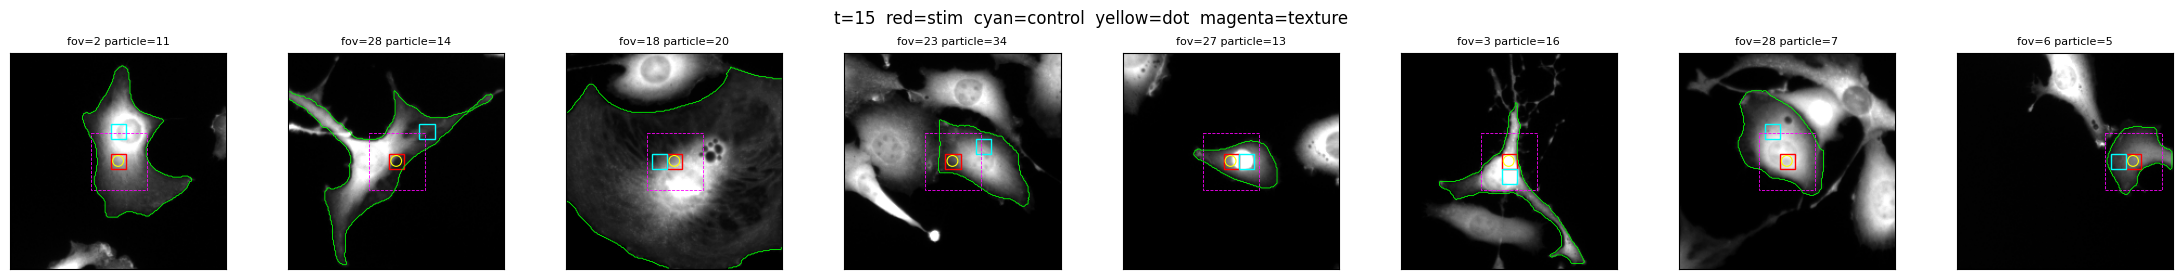

In [9]:
TEXTURE_WINDOW = 52     # GLCMTexture.window_size
VIT_PATCH_SIZE = 16     # DINOv3 backbone patch size
DINO_STRIDE    = 4      # JAFAR output stride (pixels per output token); 4 = 16x finer than native ViT
PREVIEW_T      = int(stim_table["fov_timestep"].min())
PREVIEW_CH     = 0

if PATCH_SIZE % DINO_STRIDE != 0:
    print(f"NOTE: PATCH_SIZE={PATCH_SIZE} is not a multiple of "
          f"DINO_STRIDE={DINO_STRIDE} - some output tokens straddle patch edges, "
          "the per-patch average still works but isn't pixel-exact.")

sa.plot_patch_overlays(
    raw, labels, patches_long, t=PREVIEW_T,
    channel_idx=PREVIEW_CH,
    patch_size=PATCH_SIZE,
    dot_diameter=DOT_DIAMETER,
    texture_window=TEXTURE_WINDOW,
    n_cells=8,
)

### 3b. DINO feature preview (PCA-RGB)

Forward one frame through DINOv3 and reduce the `(n_h, n_w, 384)` token grid to a 3-channel RGB image via PCA. This shows roughly what DINO "sees" -- regions with similar embeddings get similar colours. Useful for confirming the model is loaded correctly before running the full extraction.

DINO grid: (200, 256, 384)  ->  per-cell PCA-RGB: (200, 256, 3)  (stride=4 px/token)


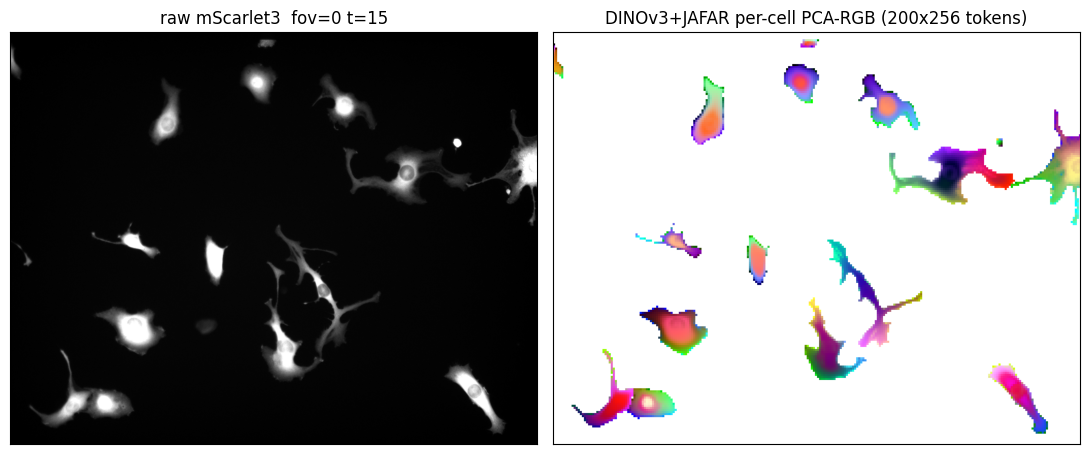

In [10]:
# Fresh JAFAR-upscaled DINO instance on the mScarlet3 channel.
dino_preview = sa.DINOv3JafarPatch(
    channel_idx=ch_idx["mScarlet3"],
    vit_patch_size=VIT_PATCH_SIZE,
    output_stride=DINO_STRIDE,
)
preview_frame = np.asarray(raw[PREVIEW_T, 0, :len(IMAGING_CHANNELS)])
dino_preview.prepare_frame(preview_frame, PREVIEW_T, 0)

# Downsample the seg-label image to the DINO token grid by sampling the
# centre pixel of each token's footprint. We use labels_seg (seg labels)
# so 0 is unambiguously background; particles/0 collides particle id 0
# with background.
img = preview_frame[ch_idx["mScarlet3"]]
H, W = img.shape
n_h, n_w = dino_preview._features.shape[:2]
sy, sx = max(1, H // n_h), max(1, W // n_w)
labels_full = np.asarray(labels_seg[PREVIEW_T, 0])
labels_at_grid = labels_full[sy // 2 :: sy, sx // 2 :: sx][:n_h, :n_w]

# Per-cell PCA: each cell gets its own component basis, so the colours
# describe within-cell variation (nucleus vs cytoplasm, edges, dense
# regions). Global PCA over the whole image is dominated by DINO's
# positional embedding -- left-vs-right artefacts swamp the actual
# subcellular structure.
rgb = sa.dino_features_pca_rgb_per_cell(
    dino_preview._features, labels_at_grid, min_tokens_per_cell=6
)
print(f"DINO grid: {dino_preview._features.shape}  ->  per-cell PCA-RGB: {rgb.shape}  (stride={DINO_STRIDE} px/token)")

# Upsample to image resolution by nearest-neighbour so the RGB lines up
# pixel-for-pixel with the raw image.
rgb_full = np.repeat(np.repeat(rgb, sy, axis=0), sx, axis=1)[:H, :W]

lo, hi = np.percentile(img, [1, 99])
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].imshow(img, cmap="gray", vmin=lo, vmax=hi)
axs[0].set_title(f"raw mScarlet3  fov=0 t={PREVIEW_T}")
axs[1].imshow(rgb_full)
axs[1].set_title(f"DINOv3+JAFAR per-cell PCA-RGB ({n_h}x{n_w} tokens)")
for ax in axs:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

## 4. Configure feature extractors

Each extractor declares its `column_names` and an `extract(frame_imgs, y_min, x_min, patch_size)` method. The driver loads each frame once and applies every extractor to every patch on that frame  -  adding a feature is just appending to the `extractors` list.

DINOv3 note: the current 14 px stim region doesn't tile evenly under DINOv3's 12 px ViT patch, so the extractor picks the ViT token closest to the stim centre. Update `PATCH_SIZE` to a 12 px multiple once we re-run the rig with a DINOv3-aligned region.

In [11]:
extractors = [
    sa.MeanIntensity(
        channels=ch_idx,
        dot_mask=sa.make_dot_mask(PATCH_SIZE, DOT_DIAMETER),
    ),
    sa.GLCMTexture(
        channels={"miRFP": ch_idx["miRFP"]},
        window_size=TEXTURE_WINDOW,
    ),
    # DINOv3 + JAFAR upscaler: feature grid at output_stride pixels per
    # token (vs the native 16 px patch). The stim region's feature is the
    # average of all upscaled tokens that lie under the 14 px patch -
    # localizes features to the actual stim area rather than to the
    # surrounding ViT patch.
    sa.DINOv3JafarPatch(
        channel_idx=ch_idx["mScarlet3"],
        backbone_name="vit_small_plus_patch16_dinov3.lvd1689m",
        vit_patch_size=VIT_PATCH_SIZE,
        output_stride=DINO_STRIDE,
        feat_dim=384,
    ),
]
for ext in extractors:
    print(f"  {type(ext).__name__}: {len(ext.column_names)} columns")

dino_ext = next(e for e in extractors if isinstance(e, sa.DINOv3JafarPatch))

  MeanIntensity: 4 columns
  GLCMTexture: 8 columns
  DINOv3JafarPatch: 384 columns


## 5. Run extraction (frame-major)

One pass over `(fov, t)`. Each `(t, fov)` zarr frame is loaded exactly once and every extractor runs against every patch. The result is a long-form features table  -  no QC has been applied yet.

In [12]:
# Cache-or-recompute: load features_long.parquet if it exists, otherwise
# run the extraction and write it back. Flip FORCE_REEXTRACT to True when
# you've changed the extractor configuration or the patches table and
# want to invalidate the cache.
features_path = path / "features_long.parquet"
FORCE_REEXTRACT = True

# Cell-mask loader: makes intensity readings (MeanIntensity) measure ONLY
# the cell's pixels at each frame, ignoring background. Without this, a
# cell migrating into the stim region looks like "response" purely
# because background gets replaced with cell signal. DINO / GLCM
# extractors deliberately don't use this mask (they want surrounding
# context).
cell_mask_loader = sa.make_cell_mask_loader(df_exp, _seg_labels_loader)

if features_path.exists() and not FORCE_REEXTRACT:
    features_long = pd.read_parquet(features_path)
    print(f"loaded cached features_long from {features_path}")
else:
    features_long = sa.extract_features(
        raw, patches_long, extractors,
        n_imaging_channels=len(IMAGING_CHANNELS),
        patch_size=PATCH_SIZE,
        cell_mask_loader=cell_mask_loader,
    )
    features_long.to_parquet(features_path)
    print(f"wrote {features_path}")
print("features_long:", features_long.shape)
features_long.head()

extracting:   0%|          | 0/2550 [00:00<?, ?frame/s]

wrote Z:\lhinder\data\rtm_mm_data\exp_434\random_stim_per_cell_14px_patches\features_long.parquet
features_long: (95400, 400)


,fov,particle,role,fov_timestep,mean_mScarlet3,dot_mean_mScarlet3,mean_miRFP,dot_mean_miRFP,tex_miRFP_mean,tex_miRFP_std,...,dino_f374,dino_f375,dino_f376,dino_f377,dino_f378,dino_f379,dino_f380,dino_f381,dino_f382,dino_f383
0,0,1,control,0,5748.744898,5898.9125,728.357143,729.5625,707.832092,122.317505,...,0.326670,-0.555920,0.686192,-0.325499,0.040057,0.266217,-0.077386,-0.043228,-0.248025,-0.484846
1,0,1,control,1,5321.167539,5294.8625,722.198953,723.2875,710.600952,123.397972,...,0.391547,-0.627991,0.599050,-0.315838,0.105538,0.308873,-0.104785,0.023285,-0.365049,-0.338317
2,0,1,control,2,5235.403141,5191.3250,726.000000,725.5875,712.774780,126.499184,...,0.346887,-0.627480,0.579427,-0.326005,0.106853,0.322160,-0.105535,-0.014079,-0.289991,-0.330544
3,0,1,control,3,5246.409326,5184.6875,728.476684,722.4000,716.774414,124.050323,...,0.385991,-0.625108,0.603448,-0.336322,0.116139,0.273265,-0.082520,0.001309,-0.303907,-0.402143
4,0,1,control,4,5197.974359,5215.3375,721.933333,726.8375,719.290283,125.040161,...,0.398555,-0.596452,0.639169,-0.344450,0.108262,0.230422,-0.099202,-0.014042,-0.265950,-0.421278


## 6. Baseline-normalize

Divide each cell + role's dot intensity by its own median over the pre-stim frames. The resulting `*_fold` columns are comparable across cells with different absolute expression.

In [13]:
stim_frames = sorted(stim_table["fov_timestep"].astype(int).unique())
baseline_frames = list(range(0, stim_frames[0])) if stim_frames else []
print(f"stim frames: {stim_frames[:3]}..{stim_frames[-1:]}")
print(f"baseline frames used: {baseline_frames}")

# Only normalize the RAW intensity columns. If features_long came from the
# parquet cache, it may already have stale `_baseline` / `_fold` columns
# from a previous run -- drop them and let baseline_normalize regenerate
# from the current baseline_frames, otherwise the merge inside collides
# and triggers a KeyError on `_baseline` lookup.
features_long = features_long.drop(
    columns=[c for c in features_long.columns
             if c.endswith("_baseline") or c.endswith("_fold")],
    errors="ignore",
)
dot_cols = [
    c for c in features_long.columns
    if c.startswith("dot_mean_")
]
features_long = sa.baseline_normalize(
    features_long, baseline_frames, dot_cols, method="median"
)
print("added fold columns:", [c for c in features_long.columns if c.endswith("_fold")])

stim frames: [np.int64(15)]..[np.int64(15)]
baseline frames used: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
added fold columns: ['dot_mean_mScarlet3_fold', 'dot_mean_miRFP_fold']


### 6b. Diagnostic: per-cell baseline stim vs control

For each cell, take the median dot intensity across the pre-stim frames separately for the stim and control role. If the selection is unbiased the per-cell scatter sits on the diagonal. Systematic offset -> selection bias somewhere.


baseline outliers (any channel control < 200):
  (none)


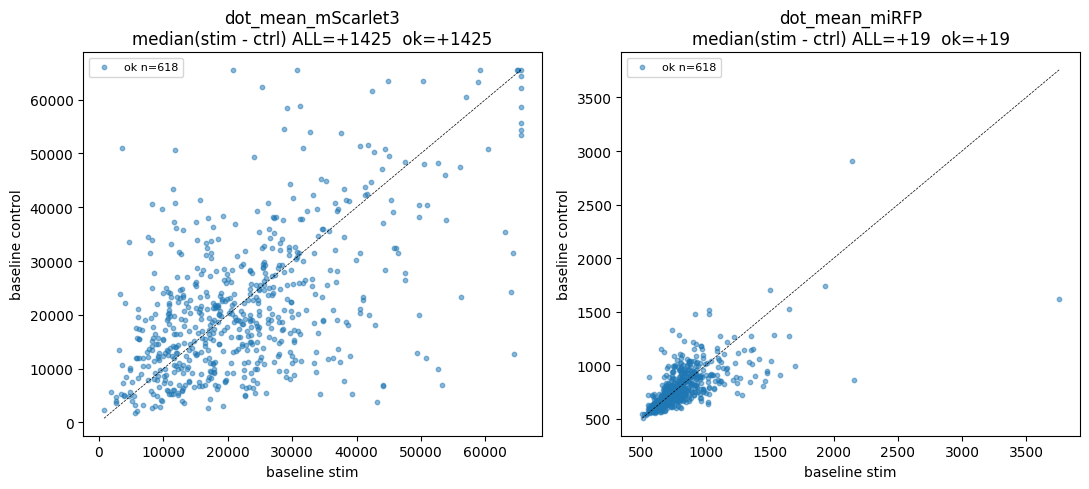

In [14]:
if not baseline_frames:
    print("no pre-stim baseline frames available - skipping")
else:
    diag_cols = [
        c for c in features_long.columns
        if c.startswith("dot_mean_") and not c.endswith("_fold") and not c.endswith("_baseline")
    ]
    base = (
        features_long[features_long["fov_timestep"].isin(baseline_frames)]
        .groupby(["fov", "particle", "role"])[diag_cols]
        .median()
        .unstack("role")
    )

    # Use a sensible "this can't be real signal" floor: anything below
    # the camera dark offset is almost certainly an off-cell / off-image
    # patch landing on a dead region. Flag those so we can see if they
    # are pulling the control mean down on their own.
    ZERO_THRESHOLD = 200.0

    fig, axs = plt.subplots(1, len(diag_cols), figsize=(5.5 * len(diag_cols), 5.0), squeeze=False)
    for i, col in enumerate(diag_cols):
        sub = base[col].dropna()
        outlier_mask = (sub["control"] < ZERO_THRESHOLD) | (sub["stim"] < ZERO_THRESHOLD)
        ok = sub[~outlier_mask]; bad = sub[outlier_mask]

        ax = axs[0, i]
        ax.scatter(ok["stim"], ok["control"], s=10, alpha=0.5, label=f"ok n={len(ok)}")
        if len(bad):
            ax.scatter(bad["stim"], bad["control"], s=20, color="red",
                       marker="x", label=f"outlier (<{ZERO_THRESHOLD:.0f}) n={len(bad)}")
        mx = max(float(sub["stim"].max()), float(sub["control"].max()))
        mn = min(float(sub["stim"].min()), float(sub["control"].min()))
        ax.plot([mn, mx], [mn, mx], "k--", lw=0.5)

        med_diff_all = float(sub["stim"].median() - sub["control"].median())
        med_diff_ok  = float(ok["stim"].median() - ok["control"].median()) if len(ok) else float("nan")
        ax.set_xlabel("baseline stim"); ax.set_ylabel("baseline control")
        ax.set_title(
            f"{col}\nmedian(stim - ctrl) ALL={med_diff_all:+.0f}  ok={med_diff_ok:+.0f}"
        )
        ax.legend(fontsize=8)
    fig.tight_layout()

    # Print the outlier cells so the user can chase the cause.
    print("\nbaseline outliers (any channel control < {:.0f}):".format(ZERO_THRESHOLD))
    outl_idx = set()
    for col in diag_cols:
        sub = base[col].dropna()
        outl_idx.update(sub[sub["control"] < ZERO_THRESHOLD].index.tolist())
    if outl_idx:
        outl_df = (
            ctrl_table.set_index(["fov", "particle"]).loc[list(outl_idx)]
            [["ctrl_patch_y_min", "ctrl_patch_x_min"]]
            .reset_index()
        )
        print(outl_df.head(20).to_string(index=False))
    else:
        print("  (none)")

## 7. Interactive QC filter

Extract-first / filter-later: re-run this cell with different thresholds without touching the (slow) extraction. `features_filtered` is what you plot from.

In [15]:
T_total = int(df_exp["fov_timestep"].nunique())

cell_stats = (
    df_exp.groupby(["fov", "particle"])
    .agg(
        cellmean_mScarlet3=("mean_intensity_C0_nuc", "mean"),
        cellmean_miRFP=("mean_intensity_C1_nuc", "mean"),
        cellmean_area=("area_nuc", "mean"),
        n_frames=("fov_timestep", "nunique"),
    )
    .reset_index()
)

# ---- thresholds  -  tweak and re-run ----
THRESH = {
    "mean_mScarlet3_min": 200,
    "mean_miRFP_min":     500,
    "area_min":          2000,
    "area_max":         12000,
    "min_frame_fraction": 0.95,
}

keep = (
    (cell_stats["cellmean_mScarlet3"] >= THRESH["mean_mScarlet3_min"])
    & (cell_stats["cellmean_miRFP"]   >= THRESH["mean_miRFP_min"])
    & cell_stats["cellmean_area"].between(THRESH["area_min"], THRESH["area_max"])
    & (cell_stats["n_frames"] >= THRESH["min_frame_fraction"] * T_total)
)
kept = cell_stats.loc[keep, ["fov", "particle"]]
print(f"kept {len(kept)}/{len(cell_stats)} cells")

features_filtered = features_long.merge(kept, on=["fov", "particle"], how="inner")
print("features_filtered:", features_filtered.shape)

kept 554/1219 cells
features_filtered: (82425, 404)


### 7b. Sample kept cells (post-filter)

Same overlay style as the pre-filter preview, but restricted to cells that survived QC. Random seed each call - re-run to flip through different examples and visually validate the selection criteria.

(<Figure size 2240x280 with 8 Axes>,
 array([[<Axes: title={'center': 'fov=24 particle=30'}>,
         <Axes: title={'center': 'fov=23 particle=37'}>,
         <Axes: title={'center': 'fov=26 particle=0'}>,
         <Axes: title={'center': 'fov=21 particle=6'}>,
         <Axes: title={'center': 'fov=20 particle=11'}>,
         <Axes: title={'center': 'fov=29 particle=5'}>,
         <Axes: title={'center': 'fov=5 particle=5'}>,
         <Axes: title={'center': 'fov=25 particle=8'}>]], dtype=object))

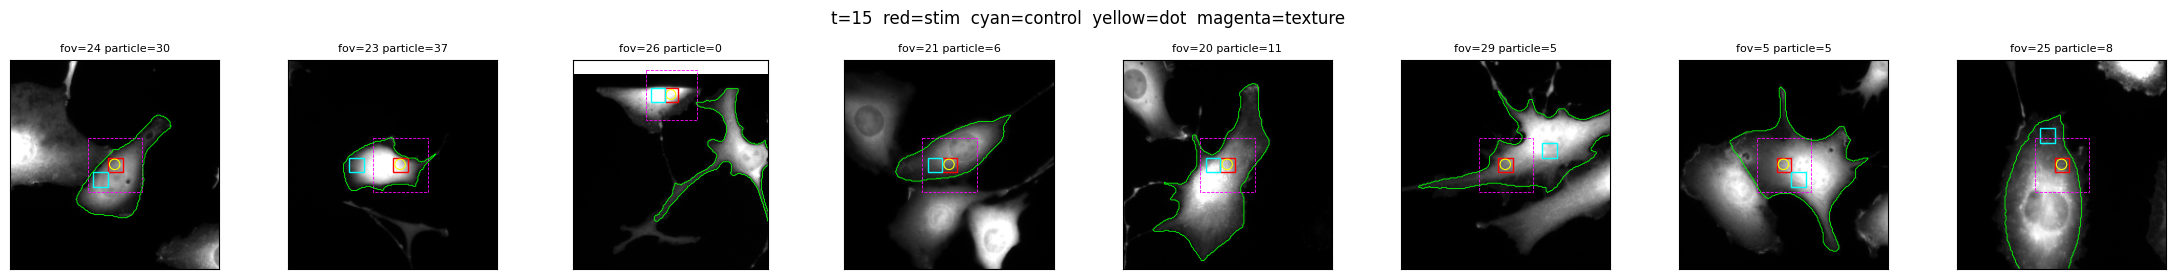

In [16]:
sa.plot_patch_overlays(
    raw, labels, patches_long, t=PREVIEW_T,
    channel_idx=PREVIEW_CH,
    patch_size=PATCH_SIZE,
    dot_diameter=DOT_DIAMETER,
    texture_window=TEXTURE_WINDOW,
    n_cells=8,
    cells=kept,
)

## 8. Stim vs. control response

Per-channel mean Â± SEM over kept cells. Raw dot intensity on the left, baseline-normalized fold change on the right. Yellow band = stim window.

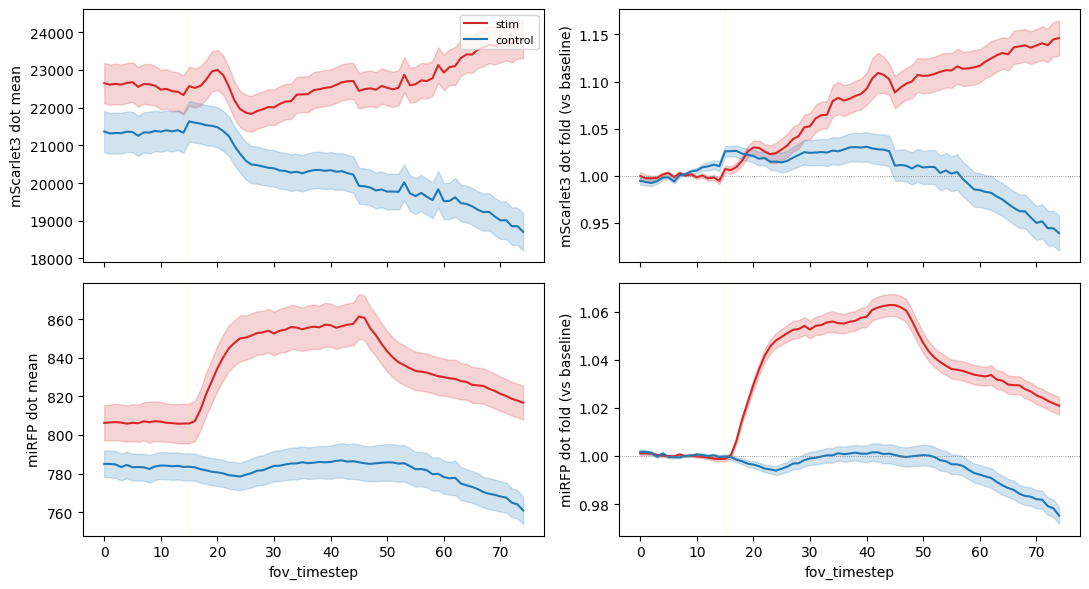

In [17]:
fig, axs = plt.subplots(
    len(IMAGING_CHANNELS), 2,
    figsize=(11, 3.0 * len(IMAGING_CHANNELS)),
    sharex=True, squeeze=False,
)
for r, ch in enumerate(IMAGING_CHANNELS):
    for c, (col, ylabel) in enumerate([
        (f"dot_mean_{ch}",      f"{ch} dot mean"),
        (f"dot_mean_{ch}_fold", f"{ch} dot fold (vs baseline)"),
    ]):
        ax = axs[r, c]
        if col not in features_filtered.columns:
            ax.set_title(f"missing {col}"); continue
        for role, color in [("stim", "C3"), ("control", "C0")]:
            sub = features_filtered[features_filtered["role"] == role]
            grp = sub.groupby("fov_timestep")[col]
            m, s = grp.mean(), grp.sem()
            ax.plot(m.index, m.values, color=color, label=role)
            ax.fill_between(m.index, m - s, m + s, color=color, alpha=0.2)
        if stim_frames:
            ax.axvspan(stim_frames[0], stim_frames[-1], color="yellow", alpha=0.15)
        if col.endswith("_fold"):
            ax.axhline(1.0, color="gray", lw=0.6, ls=":")
        ax.set_ylabel(ylabel)
        if r == 0 and c == 0:
            ax.legend(loc="upper right", fontsize=8)
axs[-1, 0].set_xlabel("fov_timestep")
axs[-1, 1].set_xlabel("fov_timestep")
fig.tight_layout()

## 9. Save

`features_long.parquet` holds every patch x frame x feature (no QC). Re-load it later to redo plotting / filtering without re-running extraction.

In [18]:
# features_long was already saved right after extraction (cell 20).
# Here we only save the post-QC subset alongside it.
features_filtered.to_parquet(path / "features_long_filtered.parquet")
print("wrote:")
print(" ", path / "features_long_filtered.parquet")
print(" ", path / "features_long.parquet  (already written during extraction)")

wrote:
  Z:\lhinder\data\rtm_mm_data\exp_434\random_stim_per_cell_14px_patches\features_long_filtered.parquet
  Z:\lhinder\data\rtm_mm_data\exp_434\random_stim_per_cell_14px_patches\features_long.parquet  (already written during extraction)


## 10. What response should we expect at each location?

For every cell, take the peak `dot_mean_*_fold` of its **stim** patch during the stim window as a scalar response value. The cell's DINO fingerprint is the average of its stim-location patch tokens across the pre-stim baseline (what the spot *looked like* before stimulation).

We then:
  1. Fit a RandomForest **regressor** on DINO -> response (continuous). Cross-validated R^2 + a Ridge baseline for context.
  2. KMeans-cluster the cells into 10 groups and report mean response per cluster.
  3. Apply the trained regressor to *every* ViT token of a few sample frames -> a predicted-response map. Each token answers "if a stim were placed here, how strongly would the cell respond?"

A binary `responder` flag is still set (threshold = median response) because section 11's trajectory heatmap sorts rows by it; the regressor doesn't use it.

In [19]:
RESPONSE_CHANNEL = "mScarlet3"
RESPONSE_COL     = f"dot_mean_{RESPONSE_CHANNEL}_fold"

# Per-cell peak response during the stim window (continuous).
resp = sa.per_cell_response_metric(
    features_filtered,
    column=RESPONSE_COL,
    stim_frames=stim_frames,
    agg="max",
    role="stim",
)
# Binary responder label kept for the trajectory heatmap's row ordering;
# the regressor below uses the continuous `response` column directly.
resp["responder"] = (resp["response"] > resp["response"].median()).astype(int)
print(f"{resp['responder'].sum()}/{len(resp)} cells above median response "
      f"(median={resp['response'].median():.2f})")

# Per-cell DINO fingerprint = mean over baseline frames at the stim patch.
X, cells_df = sa.per_cell_dino_vector(
    features_filtered,
    frames=baseline_frames if baseline_frames else stim_frames[:1],
    role="stim",
)
print(f"X: {X.shape}  cells: {len(cells_df)}")

aligned = cells_df.merge(resp, on=["fov", "particle"], how="inner")
mask = aligned["responder"].notna()
X = X[aligned.index[mask].to_numpy()]
aligned = aligned.loc[mask].reset_index(drop=True)
y_cont = aligned["response"].to_numpy().astype(np.float32)
y      = aligned["responder"].to_numpy().astype(int)
print(f"final: X={X.shape}  response range=[{y_cont.min():.2f}, {y_cont.max():.2f}]  mean={y_cont.mean():.2f}")

272/553 cells above median response (median=1.00)
X: (553, 384)  cells: 553
final: X=(553, 384)  response range=[0.50, 1.49]  mean=1.01


RandomForest 5-fold R^2: -0.085
Ridge baseline 5-fold R^2: -6.028


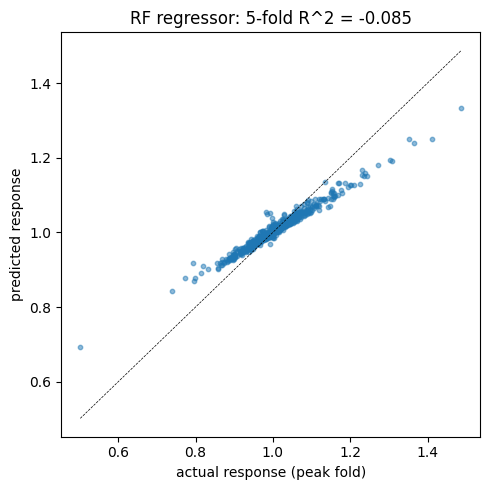

In [20]:
# RandomForest regressor (+ Ridge baseline) predicting CONTINUOUS response
# from DINO features. CV R^2 tells us how well the stim-region's structural
# fingerprint explains variance in the cell's stim response.
result = sa.fit_response_regressor(X, y_cont, cv_folds=5)
print(f"RandomForest 5-fold R^2: {result['cv_r2_rf']:.3f}")
print(f"Ridge baseline 5-fold R^2: {result['cv_r2_ridge']:.3f}")

# Predicted vs actual on the training set - a quick check that the model
# captures the response distribution (CV R^2 is the honest number, this
# is just a visualization).
y_pred = result["rf"].predict(result["scaler"].transform(X) if result["scaler"] is not None else X)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_cont, y_pred, s=10, alpha=0.5)
mn = float(min(y_cont.min(), y_pred.min()))
mx = float(max(y_cont.max(), y_pred.max()))
ax.plot([mn, mx], [mn, mx], "k--", lw=0.5)
ax.set_xlabel("actual response (peak fold)")
ax.set_ylabel("predicted response")
ax.set_title(f"RF regressor: 5-fold R^2 = {result['cv_r2_rf']:.3f}")
fig.tight_layout()

          n  responder_rate  mean_response  median_response
cluster                                                    
0        46        0.652174       1.035634         1.024788
1        81        0.567901       1.018092         1.012506
5        52        0.500000       0.997954         1.000599
9        71        0.478873       0.998035         0.998851
6        61        0.475410       1.007991         1.000000
4        17        0.470588       0.998334         0.999446
2        59        0.457627       1.008593         0.998841
3        74        0.445946       1.006775         0.995642
7        63        0.444444       0.999350         0.994745
8        29        0.379310       0.988149         0.987920


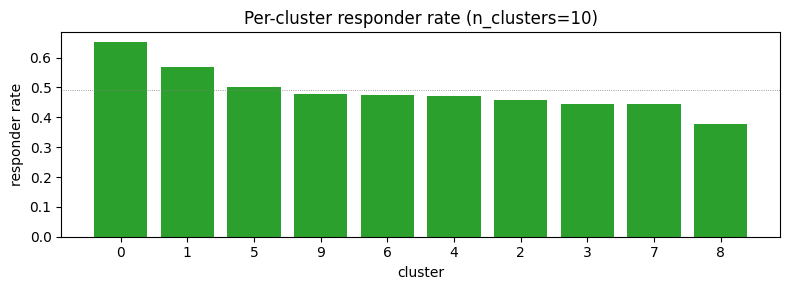

In [21]:
N_CLUSTERS = 10
aligned["cluster"] = sa.cluster_dino_features(X, n_clusters=N_CLUSTERS)

cluster_stats = (
    aligned.groupby("cluster")
    .agg(
        n=("particle", "count"),
        responder_rate=("responder", "mean"),
        mean_response=("response", "mean"),
        median_response=("response", "median"),
    )
    .sort_values("responder_rate", ascending=False)
)
print(cluster_stats.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(cluster_stats.index.astype(str), cluster_stats["responder_rate"], color="C2")
ax.set_ylabel("responder rate"); ax.set_xlabel("cluster")
ax.set_title(f"Per-cluster responder rate (n_clusters={N_CLUSTERS})")
ax.axhline(y.mean(), color="gray", lw=0.6, ls=":")
fig.tight_layout()

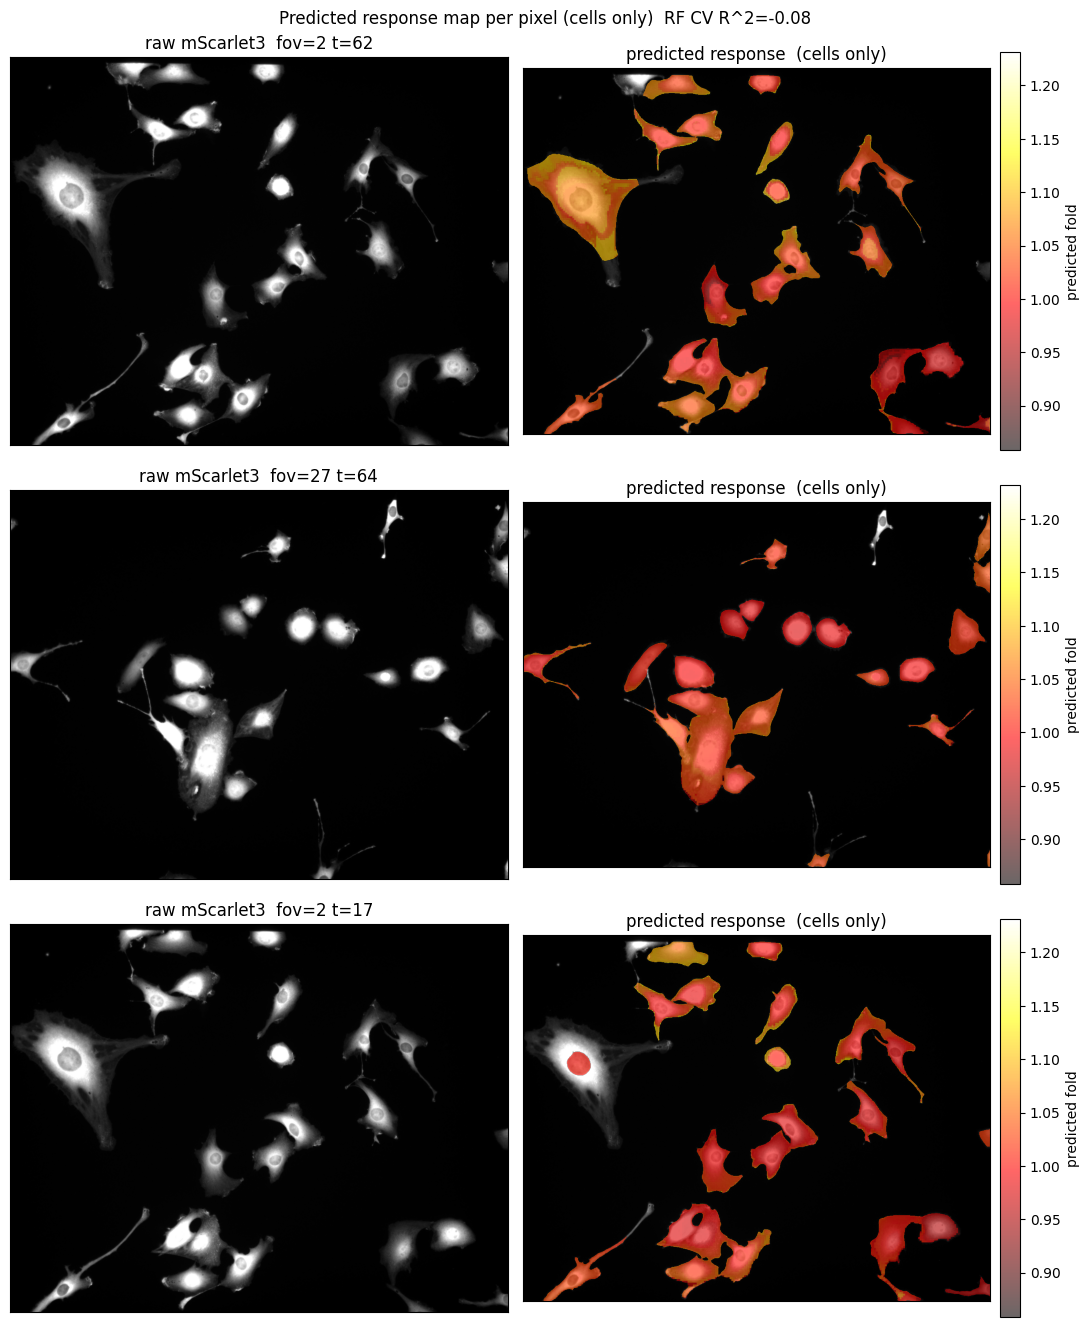

In [25]:
# Apply the regressor to every ViT token of a few random frames -> a
# spatial "predicted response" heatmap. Mask the overlay to pixels that
# actually sit on a cell (labels > 0) so the heatmap doesn't claim
# anything meaningful about background. The regressor was never trained
# on background tokens, so its predictions there are noise.
import numpy.ma as ma

N_SAMPLE_FRAMES = 3
rng = np.random.default_rng()
T_, P_ = raw.shape[0], raw.shape[1]
samples = [(int(rng.integers(T_)), int(rng.integers(P_))) for _ in range(N_SAMPLE_FRAMES)]

vmin = float(np.percentile(y_cont, 2))
vmax = float(np.percentile(y_cont, 98))

fig, axs = plt.subplots(
    N_SAMPLE_FRAMES, 2,
    figsize=(11, 4.5 * N_SAMPLE_FRAMES),
    squeeze=False,
)
for row, (t_s, fov_s) in enumerate(samples):
    frame = np.asarray(raw[t_s, fov_s, :len(IMAGING_CHANNELS)])
    dino_preview.prepare_frame(frame, t_s, fov_s)
    img = frame[ch_idx["mScarlet3"]]
    H, W = img.shape
    pred_map = sa.predict_response_map(
        result["rf"], dino_preview._features,
        scaler=result["scaler"], image_shape=(H, W),
    )
    cell_mask = np.asarray(labels[t_s, fov_s]) > 0
    pred_masked = ma.masked_where(~cell_mask, pred_map)

    lo, hi = np.percentile(img, [1, 99])
    axs[row, 0].imshow(img, cmap="gray", vmin=lo, vmax=hi)
    axs[row, 0].set_title(f"raw mScarlet3  fov={fov_s} t={t_s}")
    axs[row, 1].imshow(img, cmap="gray", vmin=lo, vmax=hi)
    overlay = axs[row, 1].imshow(
        pred_masked, cmap="hot", alpha=0.6, vmin=vmin, vmax=vmax,
    )
    axs[row, 1].set_title("predicted response  (cells only)")
    plt.colorbar(overlay, ax=axs[row, 1], fraction=0.04, pad=0.02,
                 label="predicted fold")
    for ax in axs[row]:
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(
    f"Predicted response map per pixel (cells only)  RF CV R^2={result['cv_r2_rf']:.2f}"
)
fig.tight_layout()

## 11. Per-cell miRFP fold trajectory

Heatmap of each cell's `dot_mean_miRFP_fold` trajectory (one row per cell, one column per frame). Cells sorted with responders (by mScarlet3 peak fold) on top, non-responders at the bottom -- if there's a structural signature of responsiveness in the miRFP channel, it should show up as a banding pattern in the heatmap.

C:\Users\lh21x018\AppData\Local\Temp\ipykernel_19592\1026940709.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


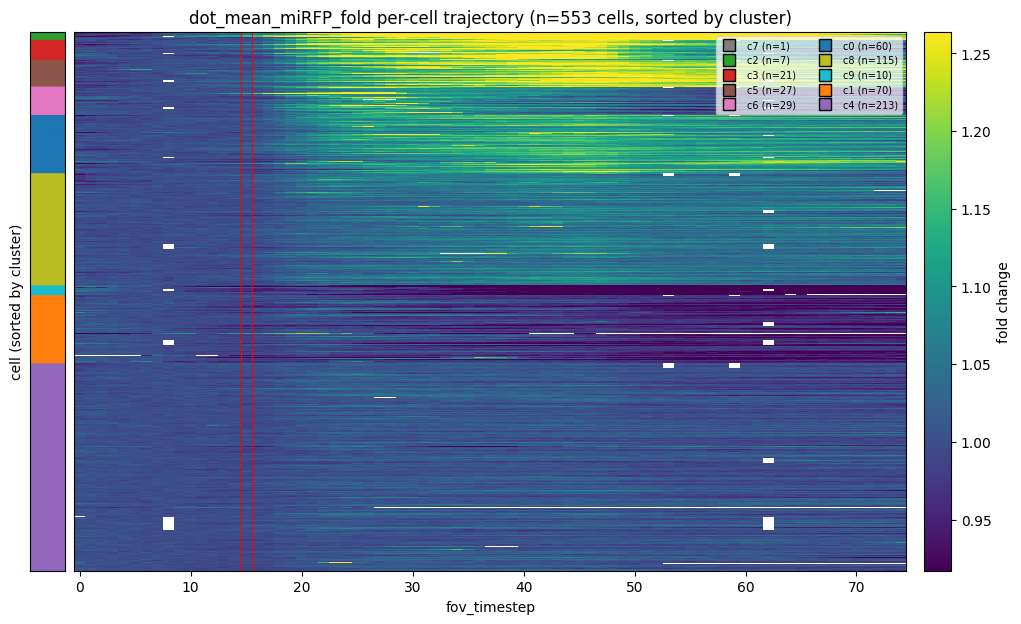

In [23]:
TRAJ_CHANNEL = "miRFP"
TRAJ_COL     = f"dot_mean_{TRAJ_CHANNEL}_fold"
N_TRAJ_CLUSTERS = 10

traj = (
    features_filtered[features_filtered["role"] == "stim"]
    .pivot_table(
        index=["fov", "particle"],
        columns="fov_timestep",
        values=TRAJ_COL,
        aggfunc="first",
    )
)
traj_X = traj.fillna(1.0).to_numpy(dtype=np.float32)
traj_clusters = sa.cluster_dino_features(traj_X, n_clusters=N_TRAJ_CLUSTERS)

# Order clusters by their mean peak fold (most-responding cluster on top)
# so adjacent rows of the heatmap come from similar response shapes.
cluster_peak = np.array([
    traj_X[traj_clusters == c].max(axis=1).mean() for c in range(N_TRAJ_CLUSTERS)
])
cluster_order = np.argsort(-cluster_peak)
cluster_rank = {int(c): r for r, c in enumerate(cluster_order)}

ordering = (
    traj.reset_index()
    .assign(cluster=traj_clusters)
    .assign(cluster_rank=lambda d: d["cluster"].map(cluster_rank))
    .sort_values(["cluster_rank", "cluster"], kind="stable")
)
sorted_traj = ordering.set_index(["fov", "particle"])[traj.columns]
sorted_clusters = ordering["cluster"].to_numpy()

import matplotlib.cm as cm
from matplotlib.lines import Line2D
cluster_colors = cm.tab10(np.linspace(0, 1, N_TRAJ_CLUSTERS))

fig, (ax_strip, ax_hm) = plt.subplots(
    1, 2, figsize=(12, 7),
    gridspec_kw={"width_ratios": [0.04, 1.0], "wspace": 0.02},
    sharey=True,
)
ax_strip.imshow(cluster_colors[sorted_clusters][:, None, :], aspect="auto")
ax_strip.set_xticks([]); ax_strip.set_yticks([])
ax_strip.set_ylabel("cell (sorted by cluster)")

vmin = float(np.nanpercentile(sorted_traj.values, 2))
vmax = float(np.nanpercentile(sorted_traj.values, 98))
im = ax_hm.imshow(sorted_traj.values, aspect="auto", cmap="viridis",
                  vmin=vmin, vmax=vmax, interpolation="nearest")
if stim_frames:
    ax_hm.axvline(stim_frames[0] - 0.5, color="red", lw=0.8)
    ax_hm.axvline(stim_frames[-1] + 0.5, color="red", lw=0.8)
ax_hm.set_xlabel("fov_timestep")
ax_hm.set_title(f"{TRAJ_COL} per-cell trajectory (n={len(sorted_traj)} cells, sorted by cluster)")
plt.colorbar(im, ax=ax_hm, fraction=0.04, pad=0.02, label="fold change")

handles = [
    Line2D([0], [0], marker="s", color="none", markerfacecolor=cluster_colors[c],
           markersize=8, label=f"c{c} (n={int((traj_clusters == c).sum())})")
    for c in cluster_order
]
ax_hm.legend(handles=handles, loc="upper right", fontsize=7, ncol=2, framealpha=0.7)
fig.tight_layout()

## 12. Cluster cells by miRFP fold trajectory

KMeans on the per-cell `dot_mean_miRFP_fold` trajectories. Different from the DINO-based clustering above -- this groups cells by *how their miRFP responds*, not by what their stim region looks like structurally. Per-cluster mean trajectory shows the dominant response shapes.

                n  responder_rate
traj_cluster                     
7               1        1.000000
2               7        0.714286
5              27        0.629630
0              60        0.616667
8             115        0.556522
6              29        0.482759
4             213        0.478873
3              21        0.476190
1              70        0.285714
9              10        0.200000


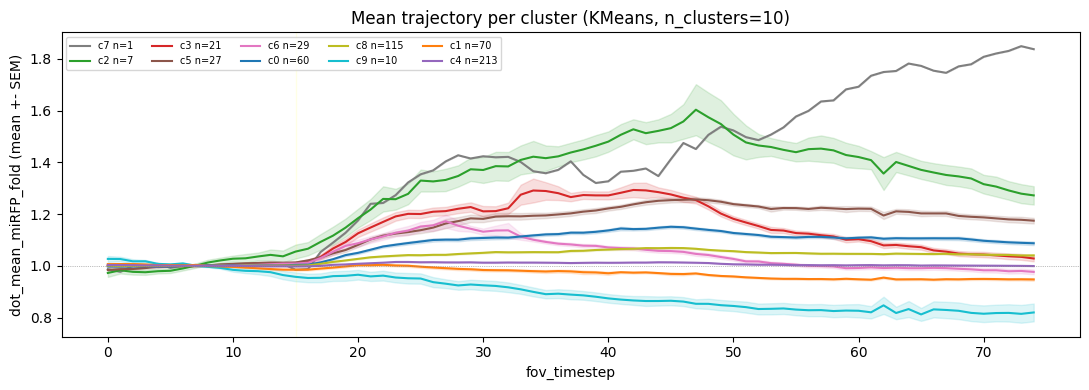

In [24]:
# Per-cluster mean trajectory using the cluster labels computed in the
# heatmap cell. Cluster colors match the strip in cell 39 so the two
# plots can be read together.
import matplotlib.cm as cm
cluster_colors = cm.tab10(np.linspace(0, 1, N_TRAJ_CLUSTERS))

clust_df = traj.reset_index()[["fov", "particle"]].copy()
clust_df["traj_cluster"] = traj_clusters
clust_df = clust_df.merge(resp[["fov", "particle", "responder"]], on=["fov", "particle"], how="left")
stats = (
    clust_df.groupby("traj_cluster")
    .agg(n=("particle", "count"), responder_rate=("responder", "mean"))
    .sort_values("responder_rate", ascending=False)
)
print(stats.to_string())

fig, ax = plt.subplots(figsize=(11, 4))
for c in cluster_order:
    members = traj_X[traj_clusters == c]
    n = len(members)
    if n == 0:
        continue
    mean = members.mean(axis=0)
    sem  = members.std(axis=0) / max(1, np.sqrt(n))
    ax.plot(traj.columns, mean, color=cluster_colors[c], label=f"c{c} n={n}")
    ax.fill_between(traj.columns, mean - sem, mean + sem,
                    color=cluster_colors[c], alpha=0.15)
if stim_frames:
    ax.axvspan(stim_frames[0], stim_frames[-1], color="yellow", alpha=0.10)
ax.axhline(1.0, color="gray", lw=0.5, ls=":")
ax.set_xlabel("fov_timestep"); ax.set_ylabel(f"{TRAJ_COL} (mean +- SEM)")
ax.set_title(f"Mean trajectory per cluster (KMeans, n_clusters={N_TRAJ_CLUSTERS})")
ax.legend(fontsize=7, ncol=5, loc="upper left")
fig.tight_layout()